In [1]:
import matplotlib.pyplot as plt

# utility functions (common functions)
def plot_total_reward(reward_history):
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.plot(range(len(reward_history)), reward_history)
    plt.show()

C:\Users\82104\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


episode :0, total reward : 26.0
episode :100, total reward : 28.0
episode :200, total reward : 14.0
episode :300, total reward : 35.0
episode :400, total reward : 25.0
episode :500, total reward : 30.0
episode :600, total reward : 36.0
episode :700, total reward : 36.0
episode :800, total reward : 27.0
episode :900, total reward : 32.0
episode :1000, total reward : 47.0
episode :1100, total reward : 61.0
episode :1200, total reward : 31.0
episode :1300, total reward : 24.0
episode :1400, total reward : 49.0
episode :1500, total reward : 46.0
episode :1600, total reward : 72.0
episode :1700, total reward : 78.0
episode :1800, total reward : 57.0
episode :1900, total reward : 19.0
episode :2000, total reward : 75.0
episode :2100, total reward : 50.0
episode :2200, total reward : 26.0
episode :2300, total reward : 50.0
episode :2400, total reward : 59.0
episode :2500, total reward : 51.0
episode :2600, total reward : 36.0
episode :2700, total reward : 27.0
episode :2800, total reward : 24

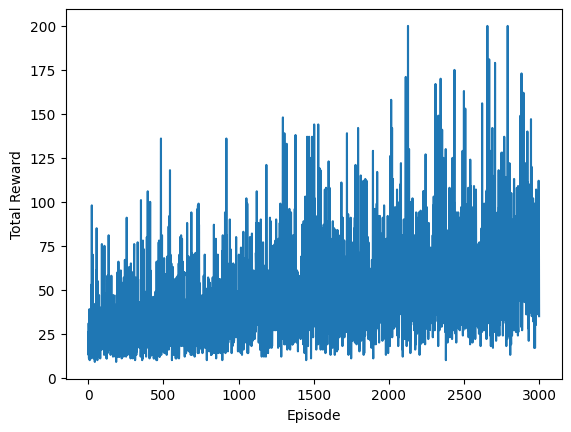

In [2]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F


class Policy(nn.Module):
    def __init__(self, action_size):
        super().__init__()
        self.l1 = nn.LazyLinear(128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x), dim=-1)
        return x


class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr = 0.0002
        self.action_size = 2

        self.memory = []
        self.pi = Policy(self.action_size)
        self.optimizer = torch.optim.Adam(
            self.pi.parameters(),
            lr=self.lr
        )

    def get_action(self, state):
        state = torch.as_tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        probs = self.pi(state)
        probs = probs[0]

        action = np.random.choice(
            len(probs),
            p=probs.detach().cpu().numpy()
        )
        return action, probs[action]

    def add(self, reward, prob):
        data = (reward, prob)
        self.memory.append(data)

    def update(self):
        self.optimizer.zero_grad()

        G, loss = 0, 0

        for reward, prob in reversed(self.memory):
            G = reward + self.gamma * G

        for reward, prob in self.memory:
            loss += -torch.log(prob) * G

        loss.backward()
        self.optimizer.step()
        self.memory = []


episodes = 3000
env = gym.make('CartPole-v0')
agent = Agent()
reward_history = []

for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        action, prob = agent.get_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.add(reward, prob)
        state = next_state
        total_reward += reward

    agent.update()

    reward_history.append(total_reward)

    if episode % 100 == 0:
        print(
            "episode :{}, total reward : {:.1f}".format(
                episode,
                total_reward
            )
        )


env.close()

# plot
plot_total_reward(reward_history)

C:\Users\82104\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


episode :0, total reward : 35.0
episode :100, total reward : 15.0
episode :200, total reward : 51.0
episode :300, total reward : 41.0
episode :400, total reward : 21.0
episode :500, total reward : 46.0
episode :600, total reward : 65.0
episode :700, total reward : 146.0
episode :800, total reward : 115.0
episode :900, total reward : 172.0
episode :1000, total reward : 41.0
episode :1100, total reward : 49.0
episode :1200, total reward : 200.0
episode :1300, total reward : 200.0
episode :1400, total reward : 200.0
episode :1500, total reward : 200.0
episode :1600, total reward : 142.0
episode :1700, total reward : 176.0
episode :1800, total reward : 108.0
episode :1900, total reward : 44.0
episode :2000, total reward : 200.0
episode :2100, total reward : 53.0
episode :2200, total reward : 122.0
episode :2300, total reward : 200.0
episode :2400, total reward : 194.0
episode :2500, total reward : 200.0
episode :2600, total reward : 200.0
episode :2700, total reward : 200.0
episode :2800, 

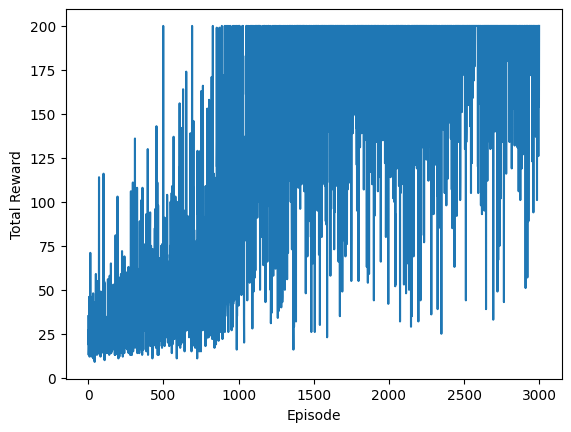

In [3]:
class Policy(nn.Module):
    def __init__(self, action_size):
        super().__init__()
        self.l1 = nn.LazyLinear(128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x), dim=-1)
        return x


class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr = 0.0002
        self.action_size = 2

        self.memory = []
        self.pi = Policy(self.action_size)
        self.optimizer = torch.optim.Adam(
            self.pi.parameters(),
            lr=self.lr
        )

    def get_action(self, state):
        state = torch.as_tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        probs = self.pi(state)
        probs = probs[0]

        action = np.random.choice(
            len(probs),
            p=probs.detach().cpu().numpy()
        )
        return action, probs[action]

    def add(self, reward, prob):
        data = (reward, prob)
        self.memory.append(data)

    def update(self):
        self.optimizer.zero_grad()

        G, loss = 0, 0

        for reward, prob in reversed(self.memory):
            G = reward + self.gamma * G
            loss += -torch.log(prob) * G

        loss.backward()
        self.optimizer.step()
        self.memory = []


episodes = 3000
env = gym.make('CartPole-v0')
agent = Agent()
reward_history = []

for episode in range(episodes):
    state, info = env.reset()
    done = False
    sum_reward = 0

    while not done:
        action, prob = agent.get_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.add(reward, prob)
        state = next_state
        sum_reward += reward

    agent.update()

    reward_history.append(sum_reward)

    if episode % 100 == 0:
        print(
            "episode :{}, total reward : {:.1f}".format(
                episode,
                sum_reward
            )
        )


env.close()

# plot
plot_total_reward(reward_history)

In [ ]:
class PolicyNet(nn.Module):
    def __init__(self, action_size=2):
        super().__init__()
        self.l1 = nn.LazyLinear(128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        x = F.softmax(x, dim=-1)
        return x


class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.LazyLinear(128)
        self.l2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        return x


class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr_pi = 0.0002
        self.lr_v = 0.0005
        self.action_size = 2

        self.pi = PolicyNet()
        self.v = ValueNet()

        self.optimizer_pi = torch.optim.Adam(
            self.pi.parameters(),
            lr=self.lr_pi
        )
        self.optimizer_v = torch.optim.Adam(
            self.v.parameters(),
            lr=self.lr_v
        )

    def get_action(self, state):
        # add batch axis
        state = torch.as_tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        probs = self.pi(state)
        probs = probs[0]

        action = np.random.choice(
            len(probs),
            p=probs.detach().cpu().numpy()
        )
        return action, probs[action]

    def update(
        self,
        state,
        action_prob,
        reward,
        next_state,
        done
    ):
        # add batch axis
        state = torch.as_tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        next_state = torch.as_tensor(
            next_state,
            dtype=torch.float32
        ).unsqueeze(0)

        # ========== (1) Update V network ===========
        with torch.no_grad():
            target = (
                reward
                + self.gamma
                * self.v(next_state)
                * (1 - done)
            )

        v = self.v(state)
        loss_v = F.mse_loss(v, target)

        # ========== (2) Update pi network ===========
        delta = (target - v).detach()
        loss_pi = -torch.log(action_prob) * delta

        self.optimizer_v.zero_grad()
        self.optimizer_pi.zero_grad()

        loss_v.backward()
        loss_pi.backward()

        self.optimizer_v.step()
        self.optimizer_pi.step()


episodes = 3000
env = gym.make('CartPole-v0')
agent = Agent()
reward_history = []

for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        action, prob = agent.get_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.update(
            state,
            prob,
            reward,
            next_state,
            done
        )

        state = next_state
        total_reward += reward

    reward_history.append(total_reward)

    if episode % 100 == 0:
        print(
            "episode :{}, total reward : {:.1f}".format(
                episode,
                total_reward
            )
        )


env.close()

# plot
plot_total_reward(reward_history)